# AO-DEIS Sampling and Evaluation for PyTorch
This notebook provides a complete pipeline to load a trained PyTorch model, visualize different sampling methods, evaluate varying NFE (Number of Function Evaluations), and calculate the official FID score.

In [13]:
import os
import sys
import yaml
import argparse
import subprocess
import torch as th
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as tvu

sys.path.append('../../')
from th_deis.ao_deis_sampler import AODEISSampler
from th_deis import DiscreteVPSDE
from runner.schedule import Schedule
from dataset import inverse_data_transform


## 1. Load the score-based model
Here we load the configuration and the PyTorch EMA checkpoint.

In [14]:
with open('config/ddim_cifar10.yml', 'r') as f:
    config = yaml.safe_load(f)

device = th.device('cuda' if th.cuda.is_available() else 'cpu')
args = argparse.Namespace(sample_speed=10, device='cuda', method='linear')

from model.ddim import Model as DDIMModel
from model.iDDPM.unet import UNetModel

struc = config['Model']['struc']
if struc == 'DDIM':
    model = DDIMModel(args, config['Model']).to(device)
elif struc == 'iDDPM':
    model = UNetModel(args, config['Model']).to(device)

ckpt_path = 'temp/train/ema.ckpt'
model.load_state_dict(th.load(ckpt_path, map_location=device), strict=True)
model.eval()
print(f"Model {struc} loaded successfully from {ckpt_path}!")

Model DDIM loaded successfully from temp/train/ema.ckpt!


## 2. Visualization code

In [15]:
def show_samples(x, title="Generated Samples"):
    grid = tvu.make_grid(x, nrow=int(np.sqrt(x.shape[0])))
    grid = grid.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(10,10))
    plt.title(title)
    plt.axis('off')
    plt.imshow(grid)
    plt.show()

## 3. Setup AO-DEIS Sampler
Initialize the Discrete VPSDE and define the epsilon prediction function.

In [16]:
schedule = Schedule(args, config['Schedule'])
vpsde = DiscreteVPSDE(schedule.alphas_cump)

def eps_fn(x, s_t):
    vec_t = (th.ones(x.shape[0])).float().to(device) * s_t
    with th.no_grad():
        return model(x, vec_t - 1)

ao_sampler = AODEISSampler(
    vpsde,
    eps_fn,
    tau_smooth=0.1,
    order_low=1,
    order_high=3,
)

num_samples = 16
# Fix a seed for the noise so we can fairly compare different NFEs on the exact same starting noise
th.manual_seed(42)
fixed_noise = th.randn(num_samples, config['Dataset']['channels'], config['Dataset']['image_size'], config['Dataset']['image_size'], device=device)

c:\Users\walee\Downloads\ITU\DL\deis-main (1)\deis-main\deis-main\demo\discrete_celeba\../..\th_deis\vpsde.py:117: UserWarning: 
We are using a piecewise linear function to fit alpha and construct continuous time SDE
The continuous time SDE uses integer timestamps 0, 1, ... , 999 by default
The default time scheduling uses continuous time that may be suboptimal for models trained with discrete time.
Modify time scheduling in sampling algorithm and choose proper time discretization for your model if needed
  warnings.warn(


## 4. Evaluate Different NFEs (Number of Function Evaluations)
Test how the quality of your images converges extremely quickly using AO-DEIS!

Sampling 10 NFE...


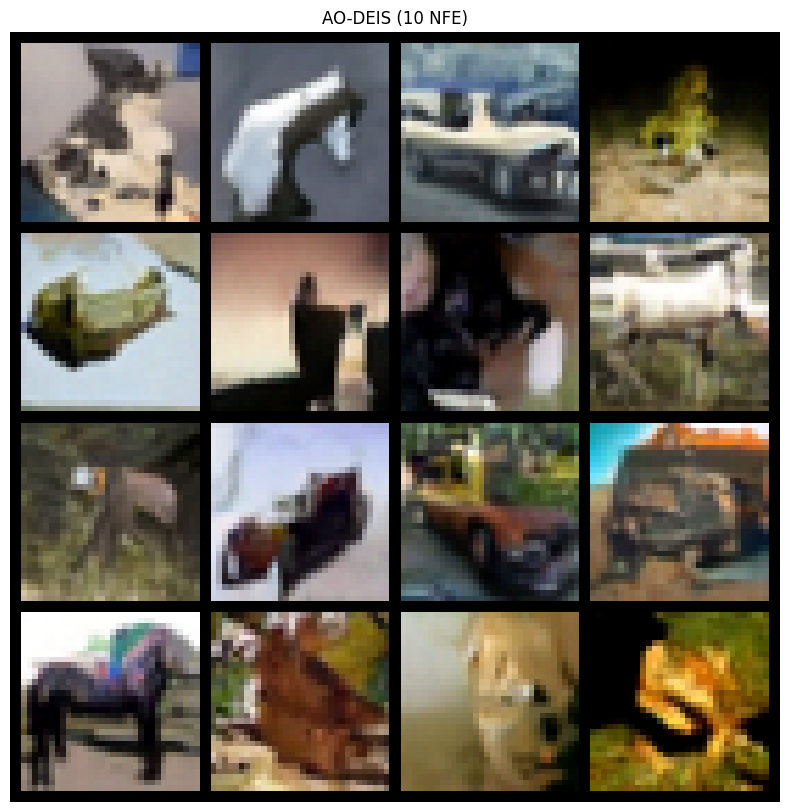

Sampling 20 NFE...


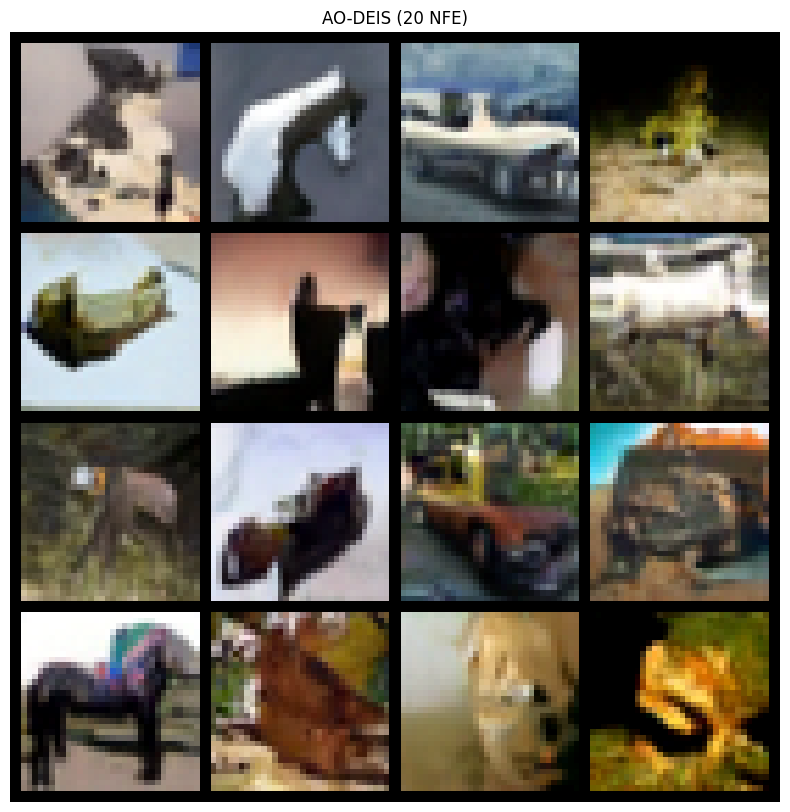

In [17]:
# Sample with 10 NFE
print("Sampling 10 NFE...")
samples_10 = ao_sampler.sample(fixed_noise.clone(), num_steps=10, ts_order=2)
samples_10 = inverse_data_transform(config['Dataset'], samples_10)
show_samples(samples_10, "AO-DEIS (10 NFE)")

# Sample with 20 NFE
print("Sampling 20 NFE...")
samples_20 = ao_sampler.sample(fixed_noise.clone(), num_steps=20, ts_order=2)
samples_20 = inverse_data_transform(config['Dataset'], samples_20)
show_samples(samples_20, "AO-DEIS (20 NFE)")

## 5. Calculate Official FID Score
This cell runs `pytorch-fid` on your generated sample directory vs the real CIFAR-10 directory directly inside the notebook.

In [18]:
print("Calculating FID Score...")
sample_dir = 'temp/sample'
real_dir = 'temp/cifar10_real'

if os.path.exists(sample_dir) and os.path.exists(real_dir):
    result = subprocess.run([sys.executable, '-m', 'pytorch_fid', sample_dir, real_dir], capture_output=True, text=True)
    print(result.stdout)
    if result.stderr:
        print("Errors/Warnings:", result.stderr)
else:
    print(f"Make sure both {sample_dir} and {real_dir} exist!")

Calculating FID Score...
FID:  20.34801022935619

Errors/Warnings: 
100%|██████████| 251/251 [00:41<00:00,  6.04it/s]

100%|██████████| 1000/1000 [01:46<00:00,  9.43it/s]

